## 🇧🇷 Seja bem vindo!
Me chamo Ígor Silva, sou estudante de ciência de dados.

Neste notebook realizamos um experimento comparando dois métodos clássicos
de representação vetorial de textos:
* Bag-of-Words (BoW)
* TF-IDF (Term Frequency – Inverse Document Frequency)

O objetivo é observar como cada abordagem transforma textos em vetores
numéricos e avaliar seu impacto em uma tarefa simples de classificação
utilizando o algoritmo KNN.

Dataset utilizado:
20 Newsgroups do Sklearn (o subconjunto utilizado conta com três categorias relacionadas a computação)

Para saber mais, acesse:
* [LinkedIn](https://www.linkedin.com/in/igordrsilva/)
* [Github](https://github.com/igordrsilva)

Divirta-se!

---
# TF-IDF 💬

---
## ⤵️ Imports

In [132]:
!pip install wordcloud

In [133]:
from sklearn import datasets, model_selection, metrics
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier

import spacy
from wordcloud import WordCloud

import pandas as pd
import numpy as np

---
## 📈 Separando os dados

In [134]:
# Selecionamos três categorias relacionadas à área de computação presentes no dataset utilizado
categories = [
  'comp.graphics',
  'comp.os.ms-windows.misc',
  'comp.sys.ibm.pc.hardware',
]

In [135]:
# Carregamento do conjunto de treino do dataset
train = datasets.fetch_20newsgroups(subset='train', categories=categories)

In [136]:
# Conversão para DataFrame para facilitar manipulação
train_df = pd.DataFrame(train.data, columns=['text'])

# Variável target numérica
train_df['target'] = train.target

# Conversão do target numérico para o nome da categoria
train_df['target_names'] = train_df.target.apply(lambda x: train.target_names[x])

# Visualização das primeiras linhas
train_df.head()

,text,target,target_names
0,From: ICH344@DJUKFA11.BITNET\nSubject: Wanted:...,2,comp.sys.ibm.pc.hardware
1,From: gay@venice.sedd.trw.com (Lance Gay)\nSub...,1,comp.os.ms-windows.misc
2,From: andrew@frip.WV.TEK.COM (Andrew Klossner)...,2,comp.sys.ibm.pc.hardware
3,From: sean@whiting.mcs.com (Sean Gum)\nSubject...,0,comp.graphics
4,From: bjorndahl@augustana.ab.ca\nSubject: Re: ...,1,comp.os.ms-windows.misc


In [137]:
# Visualizamos o tamanho do dataset original
train_df.shape

(1765, 3)

In [138]:
# Reduzimos o dataset para 500 exemplos mantendo a proporção das classes (stratify). Isso reduz o custo computacional e facilita experimentos rápidos
train_df, _ = model_selection.train_test_split(train_df, train_size=500, random_state=42, stratify=train_df['target'])

In [139]:
print(train_df.shape)

(500, 3)


---
## ⚙️ Função para lematizar textos
Função responsável por realizar a lematização dos textos.

Lematização é o processo de analisar morfologicamente a palavra e retornar palavras de mesmo significado

* bondade → bom
* corrida → correr

In [140]:
nlp = spacy.load('en_core_web_sm')
def lemmatize_text(corpus):
  lemmatized_texts = []
  for doc_text in corpus:

    # Processamento linguístico com spaCy
    doc = nlp(doc_text)

    # Mantemos apenas palavras alfabéticas e removemos espaços e símbolos
    lemmas = [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_space]
    lemmatized_texts.append(' '.join(lemmas))
  return lemmatized_texts

---
## 🗣️ Processando textos com **Bag-of-Words**

In [141]:
# Aplicamos a lematização aos textos do dataset
trein_text_lemmatized = lemmatize_text(train_df['text'])

# Neste ponto os textos já estão normalizados, lematizados e sem símbolos ou pontuação.
# Isso prepara os dados para os métodos de vetorização.
bow = CountVectorizer(
    stop_words='english', # Remove palavras muito comuns da língua inglesa
    max_df=0.95, # Remove palavras que aparecem em mais de 95% dos documentos
    min_df=0.05 # Remove palavras muito raras
)

# O método fit_transform aprende o vocabulário presente nos textos (fit) e converte cada documento em um vetor de contagem de palavras (transform)
X_train_bow = bow.fit_transform(trein_text_lemmatized) # Fit apenas nas features de teste

Na abordagem Bag-of-Words cada documento é representado como um vetor numérico que contém a contagem de cada palavra.

Exemplo simplificado:
* Documento 1: "computer graphics card"
* Documento 2: "computer hardware"

Vocabulário:
[computer, graphics, card, hardware]

Representação:

* Doc1 → [1,1,1,0]
* Doc2 → [1,0,0,1]

In [142]:
# Visualizamos algumas palavras do vocabulário aprendido
print('20 palavras aleatórias:\n')
words = bow.get_feature_names_out()
words[:100:5]

20 palavras aleatórias:



array(['able', 'allow', 'article', 'bit', 'ca', 'code', 'copy',
       'difference', 'distribution', 'email', 'file', 'gateway', 'hard',
       'hi', 'include', 'isa', 'let', 'little', 'make', 'message'],
      dtype=object)

In [143]:
# Dimensão da matriz gerada
print(f"Shape of X_train_bow: {X_train_bow.shape}")

# Número total de palavras únicas no vocabulário
print(f"Number of features (unique words): {len(bow.vocabulary_)}")

Shape of X_train_bow: (500, 190)
Number of features (unique words): 190


In [144]:
# Utilizamos o algoritmo KNN para classificar os textos com base na similaridade entre os vetores Bag-of-Words.
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(
    X_train_bow,
    train_df['target_names'].tolist()
)

KNeighborsClassifier()

In [145]:
# Realizamos a predição sobre os próprios dados de treino
prediction = knn.predict(X_train_bow)

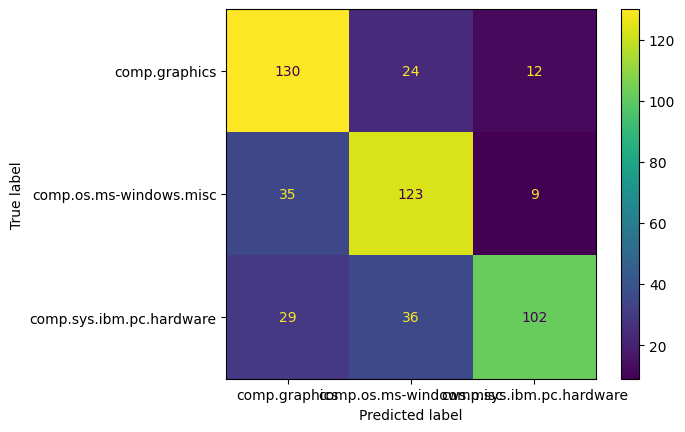

In [146]:
# Matriz de confusão para visualizar os acertos e erros
metrics.ConfusionMatrixDisplay(
    metrics.confusion_matrix(train_df.target_names.tolist(), prediction),
    display_labels=train.target_names
  ).plot()

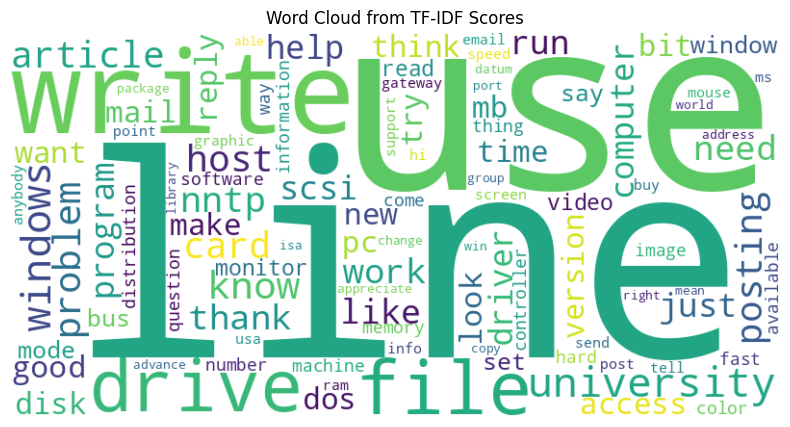

In [147]:
# Captura as palavras tokenizadas pelo BoW
feature_names = bow.get_feature_names_out()

bow_scores = X_train_bow.mean(axis=0).A1
word_bow_dict = dict(zip(feature_names, bow_scores))

# Cria uma nuvem de palavras com as mais frequentes
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate_from_frequencies(word_bow_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from TF-IDF Scores')
plt.show()

In [148]:
print(
    metrics.classification_report(
        train_df.target_names,
        prediction,
        target_names = train.target_names
    )
  )

                          precision    recall  f1-score   support

           comp.graphics       0.67      0.78      0.72       166
 comp.os.ms-windows.misc       0.67      0.74      0.70       167
comp.sys.ibm.pc.hardware       0.83      0.61      0.70       167

                accuracy                           0.71       500
               macro avg       0.72      0.71      0.71       500
            weighted avg       0.72      0.71      0.71       500



---
## 🗣️ Processando textos com **TF-IDF**
(Term Frequency - Inverse Document Frequency)

Diferente do Bag-of-Words, que considera apenas contagem de palavras, o TF-IDF atribui pesos às palavras.

Palavras muito frequentes em todos os documentos recebem peso menor.
Palavras importantes para distinguir documentos recebem peso maior.

In [149]:
tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b[A-Za-z]+\b", # ignora números, pontuação e símbolos
    max_df=0.95,
    min_df=0.05,
    stop_words='english'
)
X_train_tfidf = tfidf.fit_transform(trein_text_lemmatized)

In [150]:
# Treinamos o mesmo modelo KNN, agora utilizando os vetores TF-IDF
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(
    X_train_tfidf,
    train_df['target_names'].tolist()
)

KNeighborsClassifier()

In [151]:
prediction = knn.predict(X_train_tfidf)

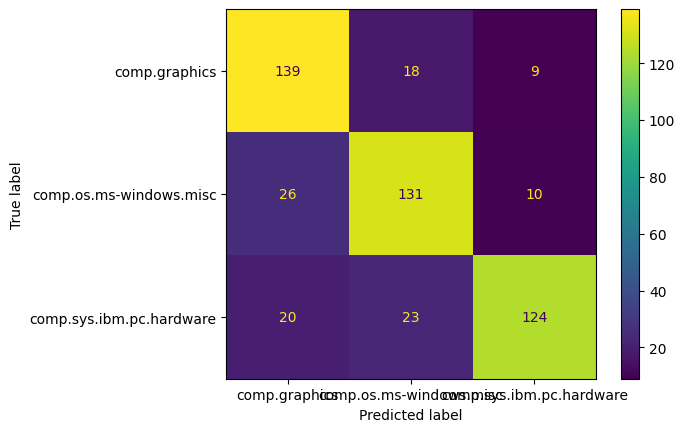

In [152]:
metrics.ConfusionMatrixDisplay(
    metrics.confusion_matrix(train_df.target_names.tolist(), prediction),
    display_labels=train.target_names
  ).plot()

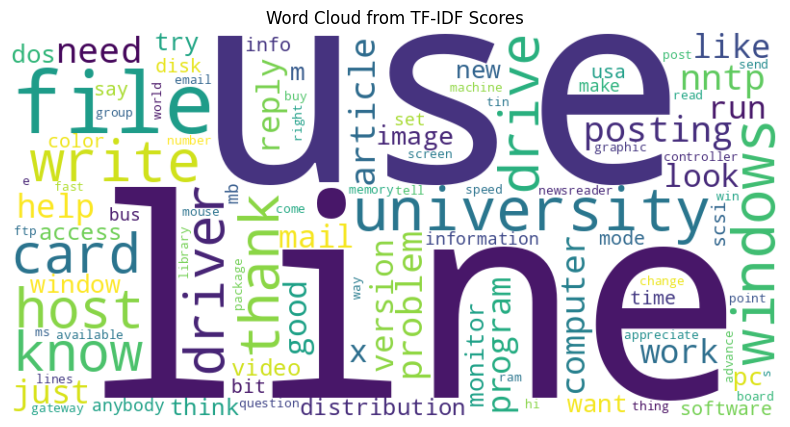

In [153]:
feature_names = tfidf.get_feature_names_out()

tfidf_scores = X_train_tfidf.mean(axis=0).A1

word_tfidf_dict = dict(zip(feature_names, tfidf_scores))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate_from_frequencies(word_tfidf_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from TF-IDF Scores')
plt.show()

In [154]:
print(
    metrics.classification_report(
        train_df.target_names,
        prediction,
        target_names = train.target_names
    )
  )

                          precision    recall  f1-score   support

           comp.graphics       0.75      0.84      0.79       166
 comp.os.ms-windows.misc       0.76      0.78      0.77       167
comp.sys.ibm.pc.hardware       0.87      0.74      0.80       167

                accuracy                           0.79       500
               macro avg       0.79      0.79      0.79       500
            weighted avg       0.79      0.79      0.79       500



---
## 🎯 Conclusões

#### **Diferenças entre BoW e TF-IDF**

O Bag-of-Words (BoW) representa documentos apenas pela contagem de palavras, tratando todas com o mesmo peso. Já o TF-IDF considera não apenas a frequência das palavras no documento, mas também sua importância relativa no conjunto de documentos, reduzindo o peso de termos muito comuns.

#### **Impacto na classificação**

Como o TF-IDF penaliza palavras frequentes e destaca termos mais informativos, ele tende a gerar representações mais discriminativas dos textos, o que pode melhorar o desempenho de algoritmos de classificação em comparação ao BoW, especialmente quando há muitas palavras comuns entre os documentos.

#### **Vantagens de cada abordagem**

O BoW é simples, rápido e fácil de interpretar, sendo útil em experimentos iniciais e modelos mais simples.
O TF-IDF, por outro lado, produz representações mais informativas dos textos, geralmente resultando em melhor capacidade de diferenciação entre documentos em tarefas de classificação.

# 🇧🇷 Espero que tenham gostado!
Caso queira mais conteúdos como este, você pode me encontrar no [LinkedIn](https://www.linkedin.com/in/igordrsilva/) ou também encontrar meus estudos no [Github](https://github.com/igordrsilva).

Abraços, até a próxima!